# Transformer for Retail Demand Forecasting

## Objective

This notebook implements a Transformer-based neural network for next-day
retail demand forecasting.

The model receives the previous 28 days of demand and predicts the
following day's demand.

The architecture uses:

- Input projection
- Positional encoding
- Multi-head self-attention
- Transformer encoder layers
- Feed-forward networks
- Residual connections
- Layer normalization
- Dropout
- Regression output layer

Self-attention allows the model to compare information across different
positions in the historical sequence.

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

if 'google.colab' in sys.modules:
    BASE = Path("/content")
else:
    BASE = Path("..").resolve()

sys.path.insert(0, str(BASE / "src"))

In [3]:
import importlib
import transformer

importlib.reload(transformer)

from transformer import TransformerRegressor

In [4]:
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [5]:
import data_splitting
import scaling
import sequence_generator

processed_path = BASE / "data" / "m5" / "processed"
results_path = BASE / "results"

sales_clean = pd.read_csv(processed_path / "sales_train_validation_clean.csv")

split = data_splitting.create_chronological_split(
    sales_clean, train_ratio=0.80, validation_ratio=0.10
)

scaler = scaling.fit_scaler_on_training_data(sales_clean, split["train"])
scaled_data = scaling.transform_sales_splits(sales_clean, split, scaler)

scaled_all = np.concatenate(
    [scaled_data["train"], scaled_data["validation"], scaled_data["test"]],
    axis=1
)

LOOKBACK = 28
train_end = split["train_days"]
validation_end = train_end + split["validation_days"]
test_end = validation_end + split["test_days"]

train_dataset = sequence_generator.RetailSequenceDataset(
    data=scaled_all, start_target=LOOKBACK, end_target=train_end, lookback=LOOKBACK
)
validation_dataset = sequence_generator.RetailSequenceDataset(
    data=scaled_all, start_target=train_end, end_target=validation_end, lookback=LOOKBACK
)
test_dataset = sequence_generator.RetailSequenceDataset(
    data=scaled_all, start_target=validation_end, end_target=test_end, lookback=LOOKBACK
)

print("Datasets recreated successfully.")

Datasets recreated successfully.


In [6]:
from torch.utils.data import DataLoader

BATCH_SIZE = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [8]:
model = TransformerRegressor(
    input_features=1,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.2
)

model = model.to(device)

print(model)

e:\dl-assignment\.venv\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


TransformerRegressor(
  (input_projection): Linear(in_features=1, out_features=64, bias=True)
  (positional_encoding): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (regressor): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
 

In [38]:
X_batch, y_batch = next(
    iter(train_loader)
)

X_batch = X_batch.to(device)

with torch.no_grad():

    predictions = model(
        X_batch
    )

print(
    "Input shape:",
    X_batch.shape
)

print(
    "Output shape:",
    predictions.shape
)

Input shape: torch.Size([256, 28, 1])
Output shape: torch.Size([256])


In [39]:
parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    "Trainable parameters:",
    parameter_count
)

Trainable parameters: 69185


In [40]:
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-5
EPOCHS = 30
PATIENCE = 5

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

In [41]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    total_samples = 0

    for X, y in loader:

        X = X.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        predictions = model(X)

        loss = criterion(
            predictions,
            y
        )

        loss.backward()

        optimizer.step()

        batch_size = X.size(0)

        running_loss += (
            loss.item() *
            batch_size
        )

        total_samples += batch_size

    return running_loss / total_samples

def evaluate_loss(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    total_samples = 0

    with torch.no_grad():

        for X, y in loader:

            X = X.to(
                device,
                non_blocking=True
            )

            y = y.to(
                device,
                non_blocking=True
            )

            predictions = model(X)

            loss = criterion(
                predictions,
                y
            )

            batch_size = X.size(0)

            running_loss += (
                loss.item() *
                batch_size
            )

            total_samples += batch_size

    return running_loss / total_samples

In [42]:
import time

# --------------------------------------------------
# Recreate Transformer from scratch
# --------------------------------------------------

model = TransformerRegressor(
    input_features=1,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.2
).to(device)

parameter_count = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", parameter_count)

LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-5
EPOCHS = 30
PATIENCE = 5

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

best_validation_loss = float("inf")
patience_counter = 0

history = {
    "train_loss": [],
    "validation_loss": []
}

checkpoint_path = str(
    results_path / "transformer_best_model.pt"
)

training_start = time.perf_counter()

for epoch in range(1, EPOCHS + 1):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    validation_loss = evaluate_loss(
        model,
        validation_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Validation Loss: {validation_loss:.6f}"
    )

    if validation_loss < best_validation_loss:

        best_validation_loss = validation_loss
        patience_counter = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch,
                "validation_loss": validation_loss,
                "parameters": parameter_count
            },
            checkpoint_path
        )

    else:

        patience_counter += 1

        if patience_counter >= PATIENCE:

            print("Early stopping triggered.")
            break

training_time = time.perf_counter() - training_start

print()
print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time / 60:.2f} minutes")

Trainable parameters: 69185
Epoch 01/30 | Train Loss: 0.324215 | Validation Loss: 0.291704
Epoch 02/30 | Train Loss: 0.312822 | Validation Loss: 0.271312
Epoch 03/30 | Train Loss: 0.309677 | Validation Loss: 0.293620
Epoch 04/30 | Train Loss: 0.307616 | Validation Loss: 0.269536
Epoch 05/30 | Train Loss: 0.308268 | Validation Loss: 0.272451
Epoch 06/30 | Train Loss: 0.306061 | Validation Loss: 0.269439
Epoch 07/30 | Train Loss: 0.305405 | Validation Loss: 0.274376
Epoch 08/30 | Train Loss: 0.305790 | Validation Loss: 0.276105
Epoch 09/30 | Train Loss: 0.305069 | Validation Loss: 0.281114
Epoch 10/30 | Train Loss: 0.305030 | Validation Loss: 0.284120
Epoch 11/30 | Train Loss: 0.304779 | Validation Loss: 0.282443
Early stopping triggered.

Training time: 39452.74 seconds
Training time: 657.55 minutes


In [43]:
history_df = pd.DataFrame({
    "epoch": range(1, len(history["train_loss"]) + 1),
    "train_loss": history["train_loss"],
    "validation_loss": history["validation_loss"]
})

metrics_dir = results_path / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

history_path = str(metrics_dir / "transformer_training_history.csv")

history_df.to_csv(
    history_path,
    index=False
)

print("Saved:", history_path)

Saved: E:\dl-assignment\results\metrics\transformer_training_history.csv


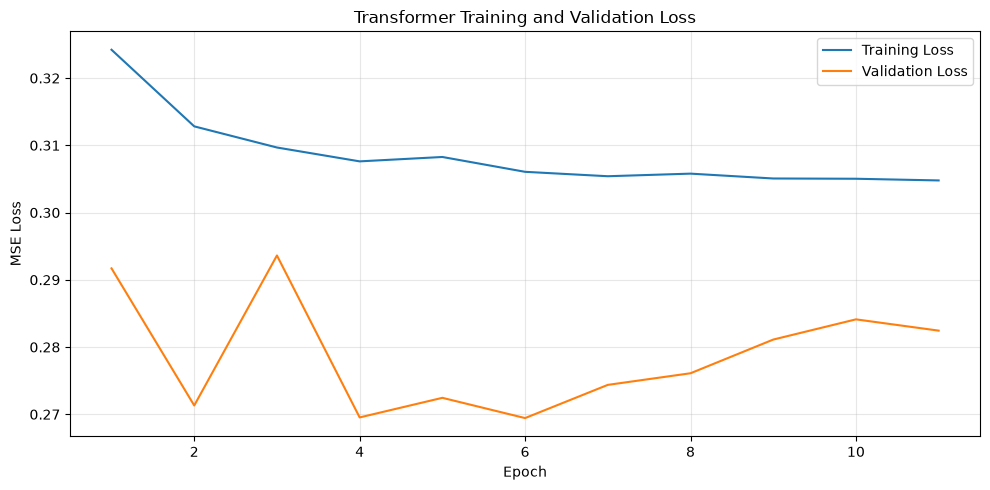

Saved: E:\dl-assignment\results\plots\transformer_learning_curve.png


In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["validation_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Transformer Training and Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plots_dir = results_path / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
transformer_plot_path = str(plots_dir / "transformer_learning_curve.png")

plt.savefig(
    transformer_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", transformer_plot_path)

In [45]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Best epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["validation_loss"])
print("Parameters:", parameter_count)
print(f"Training time: {training_time / 60:.2f} minutes")

Best epoch: 6
Best validation loss: 0.26943889669813426
Parameters: 69185
Training time: 657.55 minutes


In [46]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print(
    "Best epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation loss:",
    checkpoint["validation_loss"]
)

Best epoch: 6
Best validation loss: 0.26943889669813426


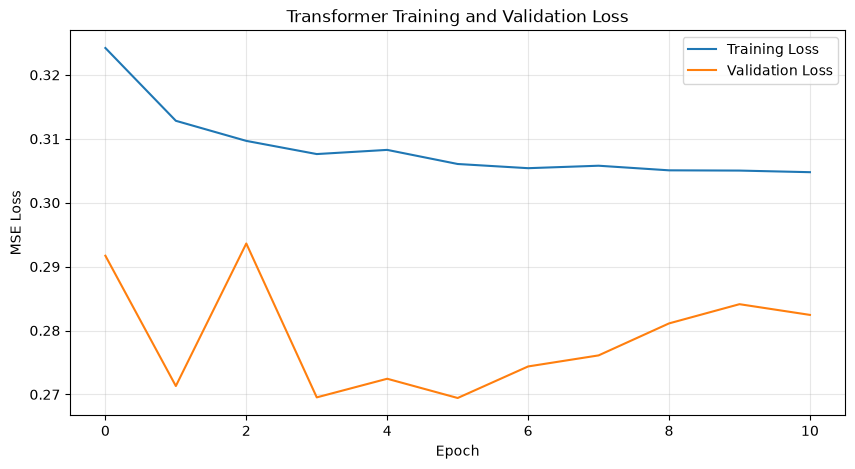

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    history["validation_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(
    "Transformer Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## TCN vs Transformer architecture comparison

At this point, don't declare one model better.

Create a table from your **actual parameter counts**:

| Property            | TCN                        | Transformer     |
| ------------------- | -------------------------- | --------------- |
| Input               | 28 × 1                     | 28 × 1          |
| Lookback            | 28 days                    | 28 days         |
| Main operation      | Causal dilated convolution | Self-attention  |
| Temporal processing | Convolution                | Attention       |
| Dilation            | 1, 2, 4, 8                 | N/A             |
| Attention heads     | N/A                        | 4               |
| Encoder layers      | N/A                        | 2               |
| Hidden dimension    | 64 max                     | 64              |
| Dropout             | 0.2                        | 0.2             |
| Output              | Next-day demand            | Next-day demand |
| Loss                | MSE                        | MSE             |
| Optimizer           | Adam                       | Adam            |

## Transformer Test Evaluation

Evaluate the saved Transformer on the unseen test period and calculate:

**MAE, MSE, RMSE, and R² in the original sales-demand scale.**

In [9]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------------
# 1. Load the best Transformer checkpoint
# --------------------------------------------------

checkpoint_path = str(results_path / "transformer_best_model.pt")

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded best Transformer checkpoint")
print("Best epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["validation_loss"])

Loaded best Transformer checkpoint
Best epoch: 6
Best validation loss: 0.26943889669813426


In [10]:
# --------------------------------------------------
# 2. Generate predictions on the unseen test set
# --------------------------------------------------

test_predictions = []
test_targets = []

with torch.no_grad():

    for X, y in test_loader:

        X = X.to(device, non_blocking=True)

        predictions = model(X)

        test_predictions.append(
            predictions.cpu().numpy()
        )

        test_targets.append(
            y.numpy()
        )

test_predictions = np.concatenate(test_predictions)
test_targets = np.concatenate(test_targets)

print("Prediction shape:", test_predictions.shape)
print("Target shape:", test_targets.shape)

Prediction shape: (5854080,)
Target shape: (5854080,)


In [11]:
# --------------------------------------------------
# 3. Convert predictions back to original demand scale
# --------------------------------------------------

predictions_original = scaler.inverse_transform(
    test_predictions.reshape(-1, 1)
).ravel()

targets_original = scaler.inverse_transform(
    test_targets.reshape(-1, 1)
).ravel()

print("Original prediction range:",
      predictions_original.min(),
      predictions_original.max())

print("Original target range:",
      targets_original.min(),
      targets_original.max())

Original prediction range: -0.028333068 186.54698
Original target range: 0.0 323.0


In [12]:
# --------------------------------------------------
# 4. Calculate test metrics
# --------------------------------------------------

mae = mean_absolute_error(
    targets_original,
    predictions_original
)

mse = mean_squared_error(
    targets_original,
    predictions_original
)

rmse = np.sqrt(mse)

r2 = r2_score(
    targets_original,
    predictions_original
)

print("\nTransformer Test Results")
print("-------------------------")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


Transformer Test Results
-------------------------
MAE  : 0.9160
MSE  : 4.1510
RMSE : 2.0374
R²   : 0.6666


In [52]:
# --------------------------------------------------
# 5. Save Transformer metrics
# --------------------------------------------------

metrics = pd.DataFrame([{
    "model": "Transformer",
    "best_epoch": checkpoint["epoch"],
    "validation_mse": checkpoint["validation_loss"],
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2,
    "parameters": parameter_count,
    "training_time_seconds": training_time,
    "training_time_minutes": training_time / 60
}])

metrics_dir = results_path / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

metrics_path = str(metrics_dir / "transformer_metrics.csv")

metrics.to_csv(
    metrics_path,
    index=False
)

print("Saved:", metrics_path)

Saved: E:\dl-assignment\results\metrics\transformer_metrics.csv


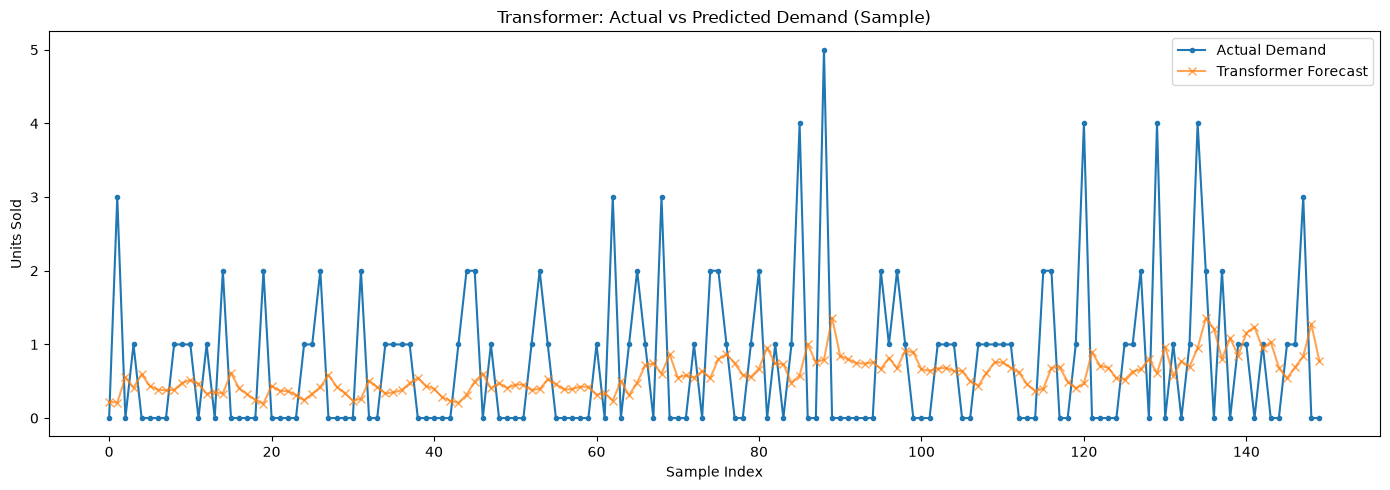

Saved Transformer forecast examples to: E:\dl-assignment\results\figures\transformer_forecast_examples.png


In [13]:
import matplotlib.pyplot as plt
from pathlib import Path

figures_dir = results_path / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(14, 5))
# Plot the first 150 test samples as an example
plt.plot(targets_original[:150], label='Actual Demand', marker='.')
plt.plot(predictions_original[:150], label='Transformer Forecast', marker='x', alpha=0.7)
plt.title('Transformer: Actual vs Predicted Demand (Sample)')
plt.xlabel('Sample Index')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()

plot_path = str(figures_dir / "transformer_forecast_examples.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print("Saved Transformer forecast examples to:", plot_path)
